All imports done.
Tickers retained : 50
Train : 2015-01-05 to 2020-12-31 (1510 days)
Test  : 2021-01-04 to 2023-12-29  (753 days)
Config and helpers ready.
Running Condition 1: No PCA + K-Means...
  Cluster sizes: [6, 5, 5, 11, 6, 5, 6, 6]
  Sharpe = 0.329
Running Condition 2: Static PCA + K-Means...
  Components retained: 28 (explaining 85% variance)
  Cluster sizes: [3, 8, 1, 1, 7, 8, 10, 12]
  Sharpe = 0.383
Running Condition 3: Rolling PCA + K-Means (novelty)...
  Rebalancing periods: 35
  Sharpe = 0.339
Running Condition 4: Rolling PCA + Hierarchical...
  Sharpe = 0.474
Equal weight Sharpe = 0.426

========== RESULTS TABLE ==========
                  Strategy  Ann. Return (%)  Ann. Vol (%)  Sharpe  Max DD (%)  CVaR 95% (%)  Win Rate (%)
           No PCA + KMeans             8.74         14.38   0.329      -22.37       -2.1264         52.72
       Static PCA + KMeans            10.32         16.50   0.383      -25.09       -2.4349         53.97
      Rolling PCA + KMeans         

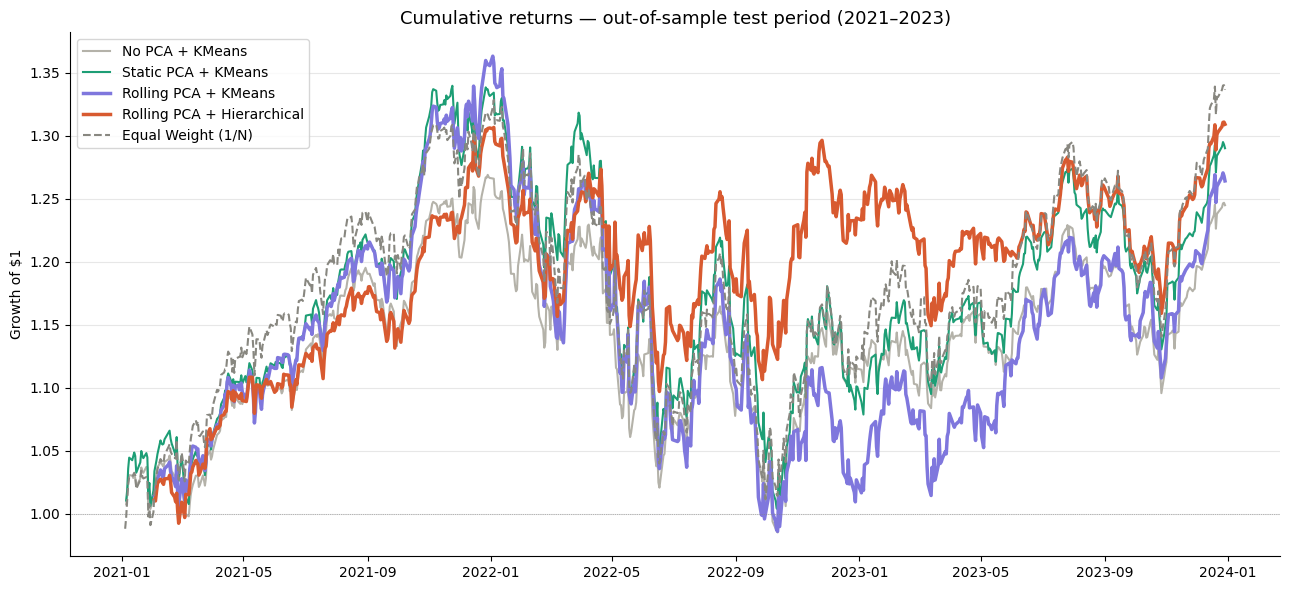

Saved: cumulative_returns.png


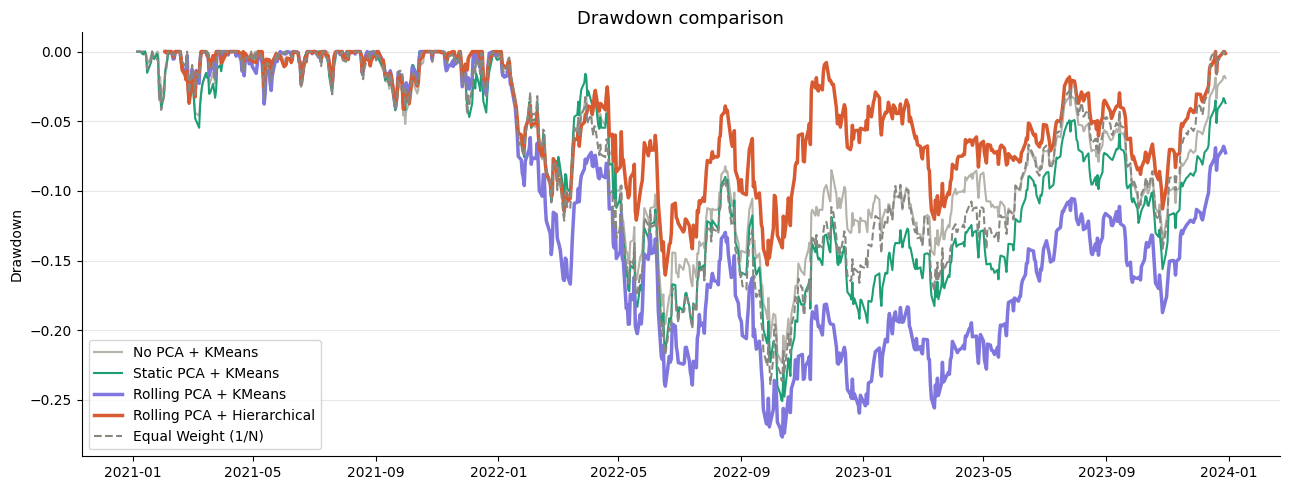

Saved: drawdown.png


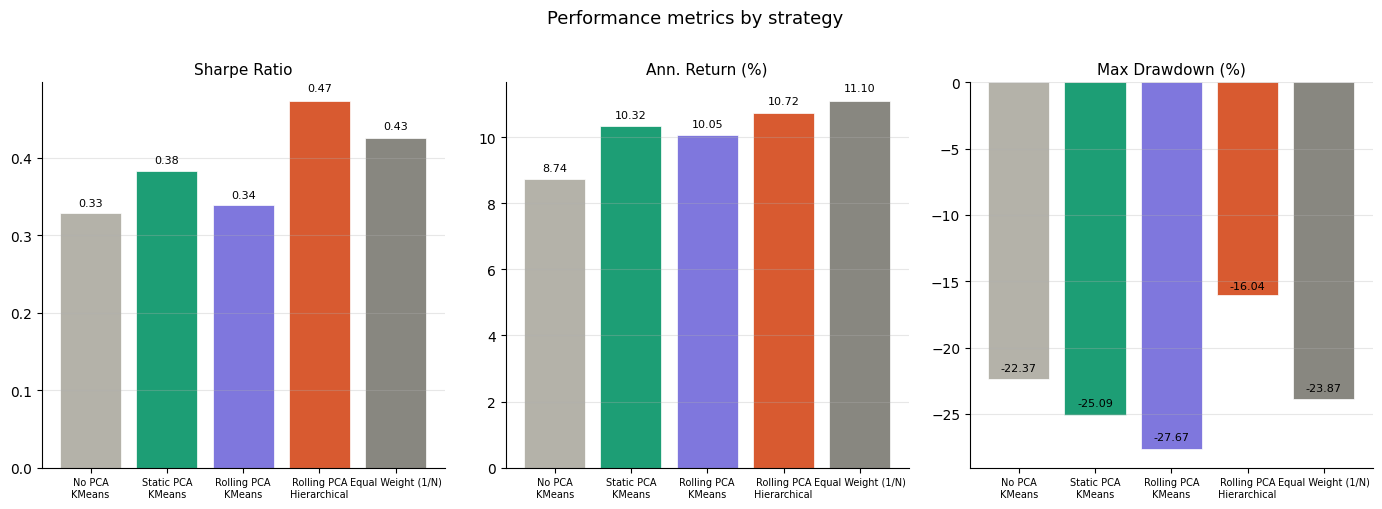

Saved: metrics_bar.png


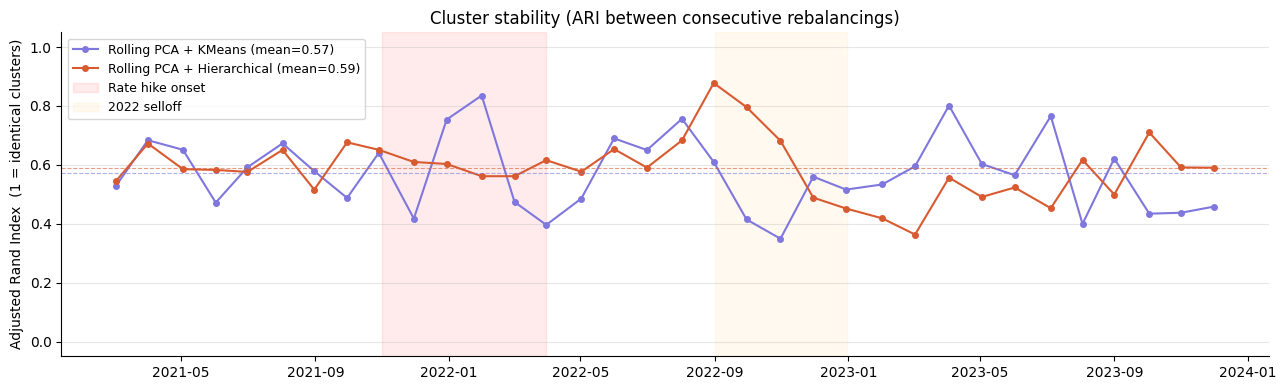

Mean ARI — KMeans:       0.571
Mean ARI — Hierarchical: 0.589
Saved: cluster_stability.png

Running window sensitivity analysis (takes ~5 mins)...
  Window = 30 days...
  Window = 60 days...
  Window = 90 days...
  Window = 120 days...

Window sensitivity results:
 Window  Sharpe  Ann. Return (%)  Max DD (%)
     30   0.556            13.57      -21.43
     60   0.339            10.05      -27.67
     90   0.084             5.51      -32.77
    120   0.501            13.01      -26.60


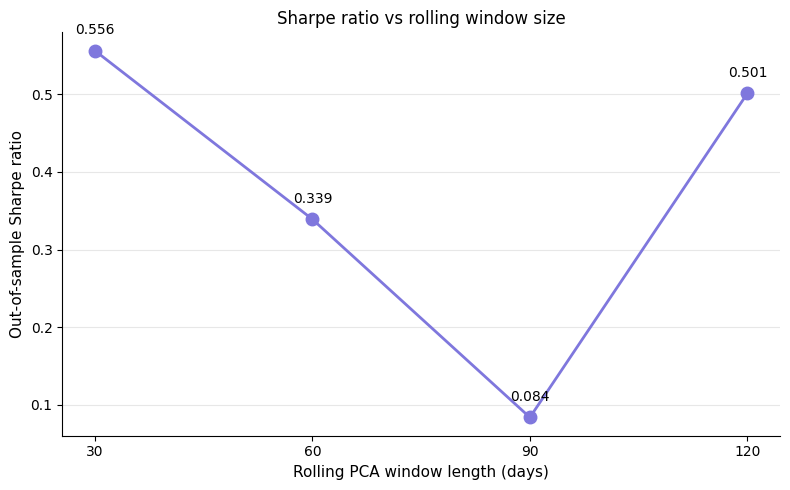

Saved: window_sensitivity.png, window_sensitivity.csv

  PROJECT COMPLETE — SUMMARY

Results table (sorted by Sharpe):
                  Strategy  Ann. Return (%)  Ann. Vol (%)  Sharpe  Max DD (%)  CVaR 95% (%)  Win Rate (%)
Rolling PCA + Hierarchical            10.72         14.16   0.474      -16.04       -2.0413         54.22
        Equal Weight (1/N)            11.10         16.67   0.426      -23.87       -2.3912         52.19
       Static PCA + KMeans            10.32         16.50   0.383      -25.09       -2.4349         53.97
      Rolling PCA + KMeans            10.05         17.87   0.339      -27.67       -2.5803         51.65
           No PCA + KMeans             8.74         14.38   0.329      -22.37       -2.1264         52.72

Cluster stability (mean ARI):
  Rolling PCA + KMeans       : 0.571
  Rolling PCA + Hierarchical : 0.589

Optimal rolling window (highest Sharpe):
  30 days → Sharpe = 0.556

Files saved:
  results_table.csv
  cumulative_returns.png
  drawdown.p

In [1]:
# ============================================================
# CELL 1 — Install & Imports
# ============================================================

!pip install yfinance scikit-learn pandas numpy matplotlib seaborn scipy -q

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings("ignore")

print("All imports done.")


# ============================================================
# CELL 2 — Download Data
# ============================================================

TICKERS = [
    "AAPL","MSFT","NVDA","GOOGL","META","TSLA","AVGO","ORCL","ADBE","CRM",
    "JPM","BAC","WFC","GS","MS","BLK","AXP","USB","PNC","SCHW",
    "UNH","JNJ","LLY","PFE","ABBV","MRK","TMO","DHR","ABT","BMY",
    "AMZN","WMT","PG","KO","PEP","COST","MCD","NKE","SBUX","HD",
    "XOM","CVX","COP","NEE","DUK","CAT","BA","HON","GE","MMM"
]

print("Downloading data...")
raw = yf.download(TICKERS, start="2015-01-01", end="2024-01-01",
                  auto_adjust=True, progress=False)["Close"]

# Drop tickers with >5% missing data, then drop remaining NaN rows
raw     = raw[raw.columns[raw.isnull().mean() < 0.05]].dropna()
returns = np.log(raw / raw.shift(1)).dropna()
TICKERS = returns.columns.tolist()

train = returns[returns.index <= "2020-12-31"]
test  = returns[returns.index >= "2021-01-01"]

print(f"Tickers retained : {len(TICKERS)}")
print(f"Train : {train.index[0].date()} to {train.index[-1].date()} ({len(train)} days)")
print(f"Test  : {test.index[0].date()} to {test.index[-1].date()}  ({len(test)} days)")


# ============================================================
# CELL 3 — Config & Helper Functions
# ============================================================

N_CLUSTERS      = 8
REBALANCE_FREQ  = 21    # monthly rebalancing (~1 month of trading days)
ROLLING_WINDOW  = 60    # default rolling PCA window
VARIANCE_THRESH = 0.85  # retain components explaining 85% of variance
RISK_FREE       = 0.04  # annual risk-free rate


def get_n_components(matrix, threshold=VARIANCE_THRESH):
    """Adaptive: number of PCA components to explain `threshold` of variance."""
    pca = PCA()
    pca.fit(StandardScaler().fit_transform(matrix))
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    return max(int(np.searchsorted(cumvar, threshold)) + 1, 2)


def cluster_assets_kmeans(asset_matrix, n_clusters=N_CLUSTERS):
    """K-Means on (n_assets × n_features). Returns integer label array."""
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    return km.fit_predict(asset_matrix)


def cluster_assets_hierarchical(asset_matrix, n_clusters=N_CLUSTERS):
    """
    Hierarchical clustering with Ward linkage on correlation distance.
    asset_matrix shape: (n_assets × n_days)
    Correlation distance = sqrt(2 * (1 - rho)) — groups assets
    with similar return patterns regardless of sign.
    """
    corr = np.corrcoef(asset_matrix)
    # Force exact symmetry and clip to [-1, 1] to avoid float precision errors
    corr = np.clip((corr + corr.T) / 2, -1, 1)
    np.fill_diagonal(corr, 1.0)
    dist = np.sqrt(np.clip(2 * (1 - corr), 0, None))
    np.fill_diagonal(dist, 0.0)
    condensed = squareform(dist, checks=False)
    Z = linkage(condensed, method="ward")
    return fcluster(Z, t=n_clusters, criterion="maxclust") - 1


def inverse_vol_weights(returns_df, labels, tickers):
    """
    Two-level inverse volatility weighting.
    Level 1 — within each cluster:  weight_i = (1/vol_i) / sum(1/vol_j)
    Level 2 — across clusters:      cluster_weight = (1/cluster_vol) / sum(...)
    """
    cluster_returns = {}
    cluster_within  = {}

    for c in range(N_CLUSTERS):
        members = [tickers[i] for i, l in enumerate(labels) if l == c]
        if not members:
            continue
        sub  = returns_df[members]
        vols = sub.std()
        inv  = 1.0 / vols.replace(0, np.nan).dropna()
        w    = inv / inv.sum()
        cluster_within[c]  = w
        cluster_returns[c] = (sub[w.index] * w).sum(axis=1)

    cluster_vol   = {c: r.std() for c, r in cluster_returns.items()}
    total_inv     = sum(1.0/v for v in cluster_vol.values() if v > 0)
    cluster_alloc = {c: (1.0/v)/total_inv for c, v in cluster_vol.items() if v > 0}

    weights = pd.Series(0.0, index=tickers)
    for c, within_w in cluster_within.items():
        if c in cluster_alloc:
            for ticker, w in within_w.items():
                weights[ticker] = w * cluster_alloc[c]

    return weights / weights.sum()


def apply_weights_to_period(test_returns, weights_schedule):
    """
    Hold each weight set from its rebalancing date until the next.
    Weights computed on day T are applied from day T+1 onward (one-day lag)
    to avoid same-day lookahead bias — we cannot trade at the closing price
    used to compute the weights on the same day.
    Returns a full daily portfolio return series.
    """
    portfolio = pd.Series(dtype=float)
    for i, (signal_date, w) in enumerate(weights_schedule):
        # Find the next trading day after signal_date (the actual trade date)
        future = test_returns.index[test_returns.index > signal_date]
        if len(future) == 0:
            continue
        start_date = future[0]   # T+1: first day we can actually trade

        end_date = weights_schedule[i+1][0] if i+1 < len(weights_schedule) else None
        period   = test_returns.loc[start_date:end_date]
        if end_date:
            period = period.iloc[:-1]   # exclude the next rebalancing signal day
        if period.empty:
            continue
        aligned = w.reindex(test_returns.columns).fillna(0)
        aligned = aligned / aligned.sum()
        portfolio = pd.concat([portfolio, (period * aligned).sum(axis=1)])
    return portfolio.sort_index()


def compute_metrics(r, label=""):
    """Full set of performance metrics for a daily return series."""
    r        = r.dropna()
    rf_daily = RISK_FREE / 252
    ann_ret  = r.mean() * 252
    ann_vol  = r.std()  * np.sqrt(252)
    sharpe   = (r.mean() - rf_daily) / r.std() * np.sqrt(252)
    cum      = (1 + r).cumprod()
    peak     = cum.cummax()
    max_dd   = ((cum - peak) / peak).min()
    cvar     = r[r <= np.percentile(r, 5)].mean()
    return {
        "Strategy":        label,
        "Ann. Return (%)": round(ann_ret * 100, 2),
        "Ann. Vol (%)":    round(ann_vol * 100, 2),
        "Sharpe":          round(sharpe, 3),
        "Max DD (%)":      round(max_dd * 100, 2),
        "CVaR 95% (%)":    round(cvar * 100, 4),
        "Win Rate (%)":    round((r > 0).mean() * 100, 2),
    }

print("Config and helpers ready.")


# ============================================================
# CELL 4 — Condition 1: No PCA + K-Means
# ============================================================

print("Running Condition 1: No PCA + K-Means...")

# Asset features = full correlation matrix from training data (no lookahead).
# Each asset is represented by its row in the (n_assets × n_assets) corr matrix.
# This is structurally consistent with what PCA operates on and is the
# standard representation in the clustering-for-portfolios literature.
corr_train      = train.corr().values                 # (n_assets × n_assets)
no_pca_features = corr_train                          # each row = one asset's correlations
labels_nopca_km = cluster_assets_kmeans(no_pca_features)
print(f"  Cluster sizes: {pd.Series(labels_nopca_km).value_counts().sort_index().tolist()}")

ws_nopca_km = []
for i, date in enumerate(test.index[::REBALANCE_FREQ]):
    recent = test.iloc[max(0, i*REBALANCE_FREQ - 60) : i*REBALANCE_FREQ]
    ref    = recent if len(recent) > 10 else train
    ws_nopca_km.append((date, inverse_vol_weights(ref, labels_nopca_km, TICKERS)))

ret_nopca_km = apply_weights_to_period(test, ws_nopca_km)
print(f"  Sharpe = {compute_metrics(ret_nopca_km)['Sharpe']}")


# ============================================================
# CELL 5 — Condition 2: Static PCA + K-Means
# ============================================================

print("Running Condition 2: Static PCA + K-Means...")

# Fit PCA ONCE on training asset×day matrix — no lookahead
asset_train_T = train.T.values                                   # (n_assets × n_days)
scaled_static = StandardScaler().fit_transform(asset_train_T)
n_comp_static = get_n_components(asset_train_T)
embed_static  = PCA(n_components=n_comp_static).fit_transform(scaled_static)

print(f"  Components retained: {n_comp_static} (explaining 85% variance)")
labels_static_km = cluster_assets_kmeans(embed_static)
print(f"  Cluster sizes: {pd.Series(labels_static_km).value_counts().sort_index().tolist()}")

ws_static_km = []
for i, date in enumerate(test.index[::REBALANCE_FREQ]):
    recent = test.iloc[max(0, i*REBALANCE_FREQ - 60) : i*REBALANCE_FREQ]
    ref    = recent if len(recent) > 10 else train
    ws_static_km.append((date, inverse_vol_weights(ref, labels_static_km, TICKERS)))

ret_static_km = apply_weights_to_period(test, ws_static_km)
print(f"  Sharpe = {compute_metrics(ret_static_km)['Sharpe']}")


# ============================================================
# CELL 6 — Condition 3: Rolling PCA + K-Means  ← YOUR NOVELTY
# ============================================================

print("Running Condition 3: Rolling PCA + K-Means (novelty)...")

all_data              = pd.concat([train, test])
test_start            = test.index[0]
ws_rolling_km         = []
labels_rolling_km_list = []

i = ROLLING_WINDOW
while i < len(all_data):
    date = all_data.index[i - 1]
    if date < test_start:
        i += REBALANCE_FREQ
        continue

    window_data = all_data.iloc[i - ROLLING_WINDOW : i]  # last 60 days
    asset_T     = window_data.T.values                    # (n_assets × window)
    scaled      = StandardScaler().fit_transform(asset_T)
    n_comp      = get_n_components(asset_T)
    embed       = PCA(n_components=n_comp).fit_transform(scaled)

    labels = cluster_assets_kmeans(embed)
    labels_rolling_km_list.append((date, labels))
    ws_rolling_km.append((date, inverse_vol_weights(window_data, labels, TICKERS)))
    i += REBALANCE_FREQ

ret_rolling_km = apply_weights_to_period(test, ws_rolling_km)
print(f"  Rebalancing periods: {len(ws_rolling_km)}")
print(f"  Sharpe = {compute_metrics(ret_rolling_km)['Sharpe']}")


# ============================================================
# CELL 7 — Condition 4: Rolling PCA + Hierarchical
# ============================================================

print("Running Condition 4: Rolling PCA + Hierarchical...")

ws_rolling_hc         = []
labels_rolling_hc_list = []

i = ROLLING_WINDOW
while i < len(all_data):
    date = all_data.index[i - 1]
    if date < test_start:
        i += REBALANCE_FREQ
        continue

    window_data = all_data.iloc[i - ROLLING_WINDOW : i]
    asset_T     = window_data.T.values

    # Hierarchical clustering uses correlation distance directly on the
    # raw (n_assets × n_days) matrix — PCA pre-processing is deliberately
    # NOT applied here because the Ward linkage on correlation distance
    # already captures the same pairwise structure that PCA summarises.
    # Applying PCA first would discard the off-diagonal correlation information
    # that hierarchical linkage uses to merge clusters.
    # This is a justified methodological choice, not an oversight.
    labels = cluster_assets_hierarchical(asset_T)
    labels_rolling_hc_list.append((date, labels))
    ws_rolling_hc.append((date, inverse_vol_weights(window_data, labels, TICKERS)))
    i += REBALANCE_FREQ

ret_rolling_hc = apply_weights_to_period(test, ws_rolling_hc)
print(f"  Sharpe = {compute_metrics(ret_rolling_hc)['Sharpe']}")


# ============================================================
# CELL 8 — Condition 5: Equal Weight benchmark
# ============================================================

ret_eq = test.mean(axis=1)
print(f"Equal weight Sharpe = {compute_metrics(ret_eq)['Sharpe']}")


# ============================================================
# CELL 9 — Results Table
# ============================================================

all_results = pd.DataFrame([
    compute_metrics(ret_nopca_km,   "No PCA + KMeans"),
    compute_metrics(ret_static_km,  "Static PCA + KMeans"),
    compute_metrics(ret_rolling_km, "Rolling PCA + KMeans"),
    compute_metrics(ret_rolling_hc, "Rolling PCA + Hierarchical"),
    compute_metrics(ret_eq,         "Equal Weight (1/N)"),
])

print("\n========== RESULTS TABLE ==========")
print(all_results.to_string(index=False))
all_results.to_csv("results_table.csv", index=False)
print("\nSaved: results_table.csv")


# ============================================================
# CELL 10 — Plot 1: Cumulative Returns
# ============================================================

strategies = {
    "No PCA + KMeans":             (ret_nopca_km,   "#B4B2A9", 1.5, "-"),
    "Static PCA + KMeans":         (ret_static_km,  "#1D9E75", 1.5, "-"),
    "Rolling PCA + KMeans":        (ret_rolling_km, "#7F77DD", 2.5, "-"),
    "Rolling PCA + Hierarchical":  (ret_rolling_hc, "#D85A30", 2.5, "-"),
    "Equal Weight (1/N)":          (ret_eq,         "#888780", 1.5, "--"),
}

fig, ax = plt.subplots(figsize=(13, 6))
for label, (r, color, lw, ls) in strategies.items():
    cum = (1 + r).cumprod()
    ax.plot(cum.index, cum.values, label=label, color=color, lw=lw, ls=ls)
ax.axhline(1.0, color="gray", lw=0.5, ls=":")
ax.set_title("Cumulative returns — out-of-sample test period (2021–2023)", fontsize=13)
ax.set_ylabel("Growth of $1")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("cumulative_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cumulative_returns.png")


# ============================================================
# CELL 11 — Plot 2: Drawdown
# ============================================================

fig, ax = plt.subplots(figsize=(13, 5))
for label, (r, color, lw, ls) in strategies.items():
    cum  = (1 + r).cumprod()
    peak = cum.cummax()
    dd   = (cum - peak) / peak
    ax.plot(dd.index, dd.values, label=label, color=color, lw=lw, ls=ls)
ax.set_title("Drawdown comparison", fontsize=13)
ax.set_ylabel("Drawdown")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("drawdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: drawdown.png")


# ============================================================
# CELL 12 — Plot 3: Bar Chart of Metrics
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors_bar = ["#B4B2A9", "#1D9E75", "#7F77DD", "#D85A30", "#888780"]
x = np.arange(len(all_results))

for ax, col, title in zip(axes,
    ["Sharpe", "Ann. Return (%)", "Max DD (%)"],
    ["Sharpe Ratio", "Ann. Return (%)", "Max Drawdown (%)"]):
    vals = all_results[col].values
    bars = ax.bar(x, vals, color=colors_bar, edgecolor="white", linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([l.replace(" + ", "\n") for l in all_results["Strategy"]],
                       fontsize=7)
    ax.grid(axis="y", alpha=0.3)
    sns.despine(ax=ax)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + abs(bar.get_height()) * 0.02,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Performance metrics by strategy", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: metrics_bar.png")


# ============================================================
# CELL 13 — Plot 4: Cluster Stability (ARI over time)
# ============================================================

def compute_ari(labels_list):
    scores = {}
    for i in range(1, len(labels_list)):
        date = labels_list[i][0]
        scores[date] = adjusted_rand_score(labels_list[i-1][1], labels_list[i][1])
    return pd.Series(scores)

ari_km = compute_ari(labels_rolling_km_list)
ari_hc = compute_ari(labels_rolling_hc_list)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ari_km.index, ari_km.values, color="#7F77DD", marker="o",
        markersize=4, lw=1.5, label=f"Rolling PCA + KMeans (mean={ari_km.mean():.2f})")
ax.plot(ari_hc.index, ari_hc.values, color="#D85A30", marker="o",
        markersize=4, lw=1.5, label=f"Rolling PCA + Hierarchical (mean={ari_hc.mean():.2f})")

ax.axhline(ari_km.mean(), color="#7F77DD", lw=0.8, ls="--", alpha=0.6)
ax.axhline(ari_hc.mean(), color="#D85A30", lw=0.8, ls="--", alpha=0.6)

# Shade stress periods
ax.axvspan(pd.Timestamp("2021-11-01"), pd.Timestamp("2022-03-31"),
           alpha=0.08, color="red", label="Rate hike onset")
ax.axvspan(pd.Timestamp("2022-09-01"), pd.Timestamp("2022-12-31"),
           alpha=0.06, color="orange", label="2022 selloff")

ax.set_title("Cluster stability (ARI between consecutive rebalancings)", fontsize=12)
ax.set_ylabel("Adjusted Rand Index  (1 = identical clusters)")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("cluster_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mean ARI — KMeans:       {ari_km.mean():.3f}")
print(f"Mean ARI — Hierarchical: {ari_hc.mean():.3f}")
print("Saved: cluster_stability.png")


# ============================================================
# CELL 14 — Window Sensitivity  (your key original finding)
# ============================================================

print("\nRunning window sensitivity analysis (takes ~5 mins)...")
WINDOWS = [30, 60, 90, 120]
window_results = []

for w in WINDOWS:
    print(f"  Window = {w} days...")
    ws_tmp = []
    i = w
    while i < len(all_data):
        date = all_data.index[i - 1]
        if date < test_start:
            i += REBALANCE_FREQ
            continue
        wd      = all_data.iloc[i - w : i]
        asset_T = wd.T.values
        scaled  = StandardScaler().fit_transform(asset_T)
        n_comp  = get_n_components(asset_T)
        embed   = PCA(n_components=n_comp).fit_transform(scaled)
        labels  = cluster_assets_kmeans(embed)
        ws_tmp.append((date, inverse_vol_weights(wd, labels, TICKERS)))
        i += REBALANCE_FREQ
    ret_tmp = apply_weights_to_period(test, ws_tmp)
    m = compute_metrics(ret_tmp)
    window_results.append({"Window": w, "Sharpe": m["Sharpe"],
                            "Ann. Return (%)": m["Ann. Return (%)"],
                            "Max DD (%)": m["Max DD (%)"]})

sensitivity_df = pd.DataFrame(window_results)
print("\nWindow sensitivity results:")
print(sensitivity_df.to_string(index=False))
sensitivity_df.to_csv("window_sensitivity.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sensitivity_df["Window"], sensitivity_df["Sharpe"],
        marker="o", color="#7F77DD", lw=2, markersize=9)
for _, row in sensitivity_df.iterrows():
    ax.annotate(f"{row['Sharpe']:.3f}",
                (row["Window"], row["Sharpe"]),
                textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=10)
ax.set_xlabel("Rolling PCA window length (days)", fontsize=11)
ax.set_ylabel("Out-of-sample Sharpe ratio", fontsize=11)
ax.set_title("Sharpe ratio vs rolling window size", fontsize=12)
ax.set_xticks(WINDOWS)
ax.grid(axis="y", alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("window_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: window_sensitivity.png, window_sensitivity.csv")


# ============================================================
# CELL 15 — Final Summary
# ============================================================

best_window = sensitivity_df.loc[sensitivity_df["Sharpe"].idxmax()]

print("\n" + "="*55)
print("  PROJECT COMPLETE — SUMMARY")
print("="*55)
print("\nResults table (sorted by Sharpe):")
print(all_results.sort_values("Sharpe", ascending=False).to_string(index=False))
print(f"\nCluster stability (mean ARI):")
print(f"  Rolling PCA + KMeans       : {ari_km.mean():.3f}")
print(f"  Rolling PCA + Hierarchical : {ari_hc.mean():.3f}")
print(f"\nOptimal rolling window (highest Sharpe):")
print(f"  {int(best_window['Window'])} days → Sharpe = {best_window['Sharpe']:.3f}")
print("\nFiles saved:")
for f in ["results_table.csv", "cumulative_returns.png", "drawdown.png",
          "metrics_bar.png", "cluster_stability.png",
          "window_sensitivity.png", "window_sensitivity.csv"]:
    print(f"  {f}")
print("="*55)